<a href="https://colab.research.google.com/github/dusandvorakcz-png/EDA-Rollercoaster/blob/main/EDA_Rollercoaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 SET UP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)

# 🔗 LOADING FROM KAGGLE

In [2]:
import os
from google.colab import userdata
os.environ["KAGGLE_API_TOKEN"]=userdata.get("KAGGLE_API_TOKEN")

In [3]:
import kagglehub
path = kagglehub.dataset_download("robikscube/rollercoaster-database")
print(path)

Using Colab cache for faster access to the 'rollercoaster-database' dataset.
/kaggle/input/rollercoaster-database


In [4]:
df = pd.read_csv(f"{path}/coaster_db.csv")

# 👀 FIRST LOOK

In [5]:
df.shape

(1087, 56)

In [6]:
df.head(5)

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,Height,Inversions,Lift/launch system,Cost,Trains,Park section,Duration,Capacity,G-force,Designer,Max vertical angle,Drop,Soft opening date,Fast Lane available,Replaced,Track layout,Fastrack available,Soft opening date.1,Closing date,Opened,Replaced by,Website,Flash Pass Available,Must transfer from wheelchair,Theme,Single rider line available,Restraint Style,Flash Pass available,Acceleration,Restraints,Name,year_introduced,latitude,longitude,Type_Main,opening_date_clean,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,Inversions_clean,Gforce_clean
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,NaN,Lift Packed,50 ft (15 m),NaN,gravity,NaN,NaN,Coney Island Cyclone Site,1:00,1600 riders per hour,2.9,LaMarcus Adna Thompson,30°,43 ft (13 m),NaN,NaN,NaN,Gravity pulled coaster,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1884,40.5740,-73.9780,Wood,1884-06-16,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,NaN,0,2.9
1,Flip Flap Railway,NaN,NaN,Sea Lion Park,Removed,1895,Wood,Lina Beecher,NaN,NaN,NaN,1.0,NaN,NaN,a single car. Riders are arranged 1 across in ...,NaN,NaN,NaN,12,Lina Beecher,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,NaN,"Cleveland, Ohio, United States",Closed,NaN,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1896,41.5800,-81.5700,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,NaN,1.0,NaN,NaN,a single car. Riders are arranged 2 across in ...,NaN,NaN,NaN,NaN,Edward A. Green,NaN,NaN,NaN,NaN,Switchback Railway,NaN,NaN,NaN,1910,NaN,Giant Racer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Edward A. Green,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [7]:
df.columns

Index(['coaster_name', 'Length', 'Speed', 'Location', 'Status', 'Opening date',
       'Type', 'Manufacturer', 'Height restriction', 'Model', 'Height',
       'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
       'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
       'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
       'Track layout', 'Fastrack available', 'Soft opening date.1',
       'Closing date', 'Opened', 'Replaced by', 'Website',
       'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
       'Single rider line available', 'Restraint Style',
       'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean', 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph', 'height_value', 'height_unit', 'height_ft',
       'Inversions_clean', 'Gforce_clean'],
      dtype='object')

In [8]:
df.dtypes

,0
coaster_name,object
Length,object
Speed,object
Location,object
Status,object
Opening date,object
Type,object
Manufacturer,object
Height restriction,object
Model,object


In [9]:
df.describe()

,Inversions,year_introduced,latitude,longitude,speed1_value,speed_mph,height_value,height_ft,Inversions_clean,Gforce_clean
count,932.000000,1087.000000,812.000000,812.000000,937.000000,937.000000,965.000000,171.000000,1087.000000,362.000000
mean,1.547210,1994.986201,38.373484,-41.595373,53.850374,48.617289,89.575171,101.996491,1.326587,3.824006
std,2.114073,23.475248,15.516596,72.285227,23.385518,16.678031,136.246444,67.329092,2.030854,0.989998
min,0.000000,1884.000000,-48.261700,-123.035700,5.000000,5.000000,4.000000,13.100000,0.000000,0.800000
25%,0.000000,1989.000000,35.031050,-84.552200,40.000000,37.300000,44.000000,51.800000,0.000000,3.400000
50%,0.000000,2000.000000,40.289800,-76.653600,50.000000,49.700000,79.000000,91.200000,0.000000,4.000000
75%,3.000000,2010.000000,44.799600,2.778100,63.000000,58.000000,113.000000,131.200000,2.000000,4.500000
max,14.000000,2022.000000,63.230900,153.426500,240.000000,149.100000,3937.000000,377.300000,14.000000,12.000000


# 🧹 DATA QUALITY & CLEANING

In [10]:
#Column selection from df.columns

df = df[['coaster_name',
    #'Length', 'Speed',
    'Location', 'Status',
    #'Opening date', #'Type',
    #'Manufacturer', 'Height restriction', 'Model', 'Height',
    #  'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
    #   'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
    #   'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
    #   'Track layout', 'Fastrack available', 'Soft opening date.1',
    #   'Closing date', 'Opened', 'Replaced by', 'Website',
    #   'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
    #    #'Single rider line available', 'Restraint Style',
    #   'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
    'year_introduced', 'latitude', 'longitude', 'Type_Main',
    'opening_date_clean',
    #'speed1', 'speed2', 'speed1_value', 'speed1_unit',
    'speed_mph',
    #'height_value', 'height_unit',
    'height_ft','Inversions_clean', 'Gforce_clean']].copy()

#The .copy() makes a brand new dataframe, not a reference to the old one.

In [11]:
#Data type change
df["opening_date_clean"] = pd.to_datetime(df['opening_date_clean'])
df.dtypes

,0
coaster_name,object
Location,object
Status,object
year_introduced,int64
latitude,float64
longitude,float64
Type_Main,object
opening_date_clean,datetime64[ns]
speed_mph,float64
height_ft,float64


In [12]:
#Renaming columns
df = df.rename(columns={
                   "coaster_name":"Coaster_Name",
                   "year_introduced":"Year_Introduced",
                   "latitude":"Latitude",
                   "longitude":"Longitude",
                   "Type_Main":"Type_Main",
                   "opening_date":"Opening_date",
                   "speed_mph":"Speed_mph",
                   "height_ft":"Height_ft",
                    "opening_date_clean":"Opening_date",
                   "Inversions_clean":"Inversions",
                   "Gforce_clean":"Gforce"})
df

,Coaster_Name,Location,Status,Year_Introduced,Latitude,Longitude,Type_Main,Opening_date,Speed_mph,Height_ft,Inversions,Gforce
0,Switchback Railway,Coney Island,Removed,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1082,American Dreier Looping,Other,NaN,2022,NaN,NaN,Steel,NaT,53.0,NaN,3,4.7
1083,Pantheon (roller coaster),Busch Gardens Williamsburg,Under construction,2022,37.2339,-76.6426,Steel,2022-01-01,73.0,NaN,2,NaN
1084,Tron Lightcycle Power Run,Other,NaN,2022,NaN,NaN,Steel,2016-06-16,59.3,NaN,0,4.0
1085,Tumbili,Kings Dominion,Under construction,2022,NaN,NaN,Steel,NaT,34.0,NaN,0,NaN


In [13]:
df.isnull().sum()

,0
Coaster_Name,0
Location,0
Status,213
Year_Introduced,0
Latitude,275
Longitude,275
Type_Main,0
Opening_date,250
Speed_mph,150
Height_ft,916


In [14]:
df.loc[df.duplicated()]

,Coaster_Name,Location,Status,Year_Introduced,Latitude,Longitude,Type_Main,Opening_date,Speed_mph,Height_ft,Inversions,Gforce


In [15]:
df.duplicated(subset=["Coaster_Name"])
df.loc[df.duplicated(subset=["Coaster_Name"])].head(5)

,Coaster_Name,Location,Status,Year_Introduced,Latitude,Longitude,Type_Main,Opening_date,Speed_mph,Height_ft,Inversions,Gforce
43,Crystal Beach Cyclone,Crystal Beach Park,Removed,1927,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0
60,Derby Racer,Revere Beach,Removed,1937,42.4200,-70.9860,Wood,1911-01-01,NaN,NaN,0,NaN
61,Blue Streak (Conneaut Lake),Conneaut Lake Park,Closed,1938,41.6349,-80.3180,Wood,1938-05-23,50.0,NaN,0,NaN
167,Big Thunder Mountain Railroad,Other,NaN,1980,NaN,NaN,Steel,NaT,35.0,NaN,0,NaN
237,Thunder Run (Canada's Wonderland),Canada's Wonderland,Operating,1986,43.8427,-79.5423,Steel,1981-05-23,39.8,32.8,0,NaN


In [16]:
df.query("Coaster_Name == 'Crystal Beach Cyclone'")

,Coaster_Name,Location,Status,Year_Introduced,Latitude,Longitude,Type_Main,Opening_date,Speed_mph,Height_ft,Inversions,Gforce
39,Crystal Beach Cyclone,Crystal Beach Park,Removed,1926,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0
43,Crystal Beach Cyclone,Crystal Beach Park,Removed,1927,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0


In [17]:
df = df.loc[~df.duplicated(subset=["Coaster_Name", "Location", "Opening_date"])].reset_index(drop=True).copy()
df

,Coaster_Name,Location,Status,Year_Introduced,Latitude,Longitude,Type_Main,Opening_date,Speed_mph,Height_ft,Inversions,Gforce
0,Switchback Railway,Coney Island,Removed,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
985,Ice Breaker (roller coaster),SeaWorld Orlando,Under construction,2022,28.4088,-81.4633,Steel,2022-02-01,52.0,NaN,0,NaN
986,Leviathan (Sea World),Sea World,Under construction,2022,-27.9574,153.4263,Wood,2022-01-01,49.7,105.0,0,NaN
987,Pantheon (roller coaster),Busch Gardens Williamsburg,Under construction,2022,37.2339,-76.6426,Steel,2022-01-01,73.0,NaN,2,NaN
988,Tumbili,Kings Dominion,Under construction,2022,NaN,NaN,Steel,NaT,34.0,NaN,0,NaN


# 📊 UNIVARIATE ANALYSIS

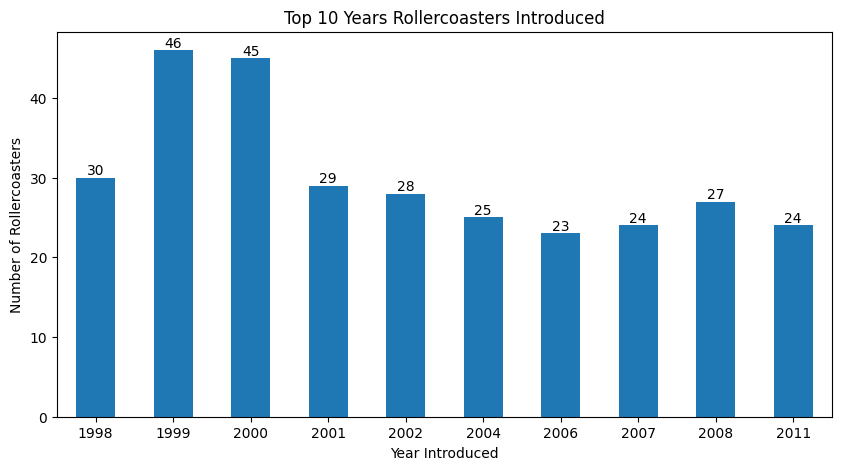

In [18]:
ax = df["Year_Introduced"].value_counts().head(10).sort_index().plot(kind="bar",
                                                   figsize=(10,5),
                                                   title="Top 10 Years Rollercoasters Introduced"
                                                    )
ax.set_xlabel("Year Introduced")
ax.set_ylabel("Number of Rollercoasters")
ax.set_xticklabels(ax.get_xticklabels(), rotation=360)
ax.bar_label(ax.containers[0])
plt.show()

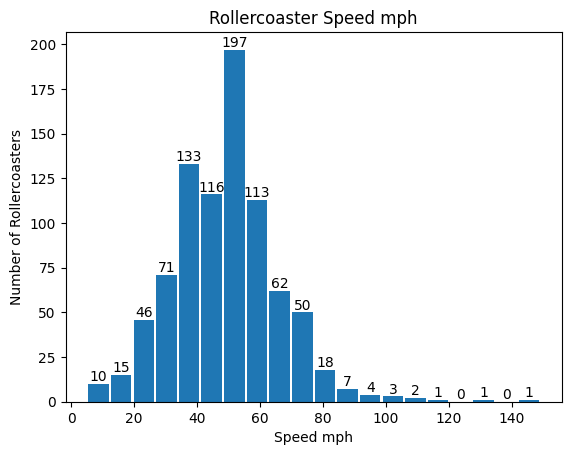

In [19]:
ax = df["Speed_mph"].plot(kind="hist",
                     bins=20,
                     title="Rollercoaster Speed mph",
                     rwidth=0.9)

ax.set_xlabel("Speed mph")
ax.set_ylabel("Number of Rollercoasters")
ax.bar_label(ax.containers[0])

plt.show()

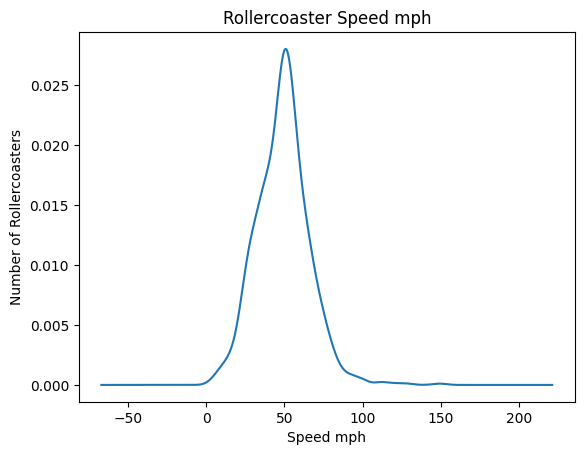

In [20]:
ax = df["Speed_mph"].plot(kind="kde",
                     title="Rollercoaster Speed mph")

ax.set_xlabel("Speed mph")
ax.set_ylabel("Number of Rollercoasters")
plt.show()

# 🔥 BIVARIATE ANALYSIS

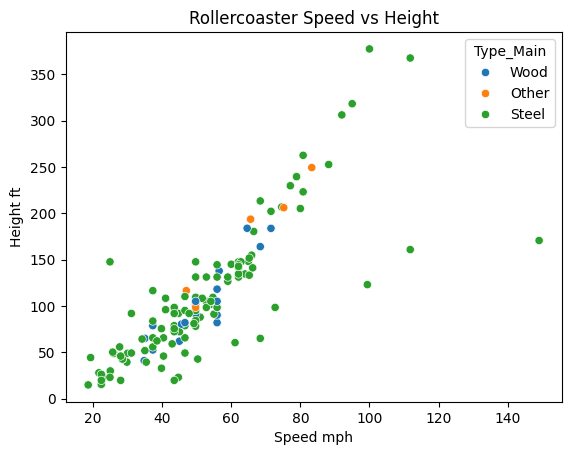

In [21]:
ax = sns.scatterplot(data=df,
                x="Speed_mph",
                y="Height_ft",
                hue="Type_Main")

ax.set_xlabel("Speed mph")
ax.set_ylabel("Height ft")
ax.set_title("Rollercoaster Speed vs Height")
plt.show()
#

In [22]:
df_corr = df.select_dtypes(include=np.number).dropna().corr().style.background_gradient(cmap="coolwarm")
df_corr

,Year_Introduced,Latitude,Longitude,Speed_mph,Height_ft,Inversions,Gforce
Year_Introduced,1.000000,-0.006157,0.042977,0.113872,0.082828,-0.250081,0.120246
Latitude,-0.006157,1.000000,-0.813104,0.066636,-0.001292,0.154118,0.226258
Longitude,0.042977,-0.813104,1.000000,-0.032952,-0.010025,-0.085222,-0.181115
Speed_mph,0.113872,0.066636,-0.032952,1.000000,0.717532,-0.027178,0.611943
Height_ft,0.082828,-0.001292,-0.010025,0.717532,1.000000,-0.074375,0.450407
Inversions,-0.250081,0.154118,-0.085222,-0.027178,-0.074375,1.000000,0.291295
Gforce,0.120246,0.226258,-0.181115,0.611943,0.450407,0.291295,1.000000


In [23]:
df.query("Location != 'Other'")\
.groupby("Location")["Speed_mph"]\
.agg(["mean", "count"])\
.query("count >=10")\
.sort_values("mean", ascending=False)

,mean,count
Location,,
Busch Gardens Williamsburg,58.318182,11
Cedar Point,57.833333,18
Six Flags Magic Mountain,57.241176,17
Canada's Wonderland,53.533333,12
Six Flags Great Adventure,53.036364,11
Kings Dominion,52.083333,12
Hersheypark,50.576923,13
Kings Island,49.273684,19
Carowinds,43.571429,14


In [24]:
result = df.query("Location != 'Other'") \
  .groupby("Location")["Speed_mph"] \
  .agg(["mean", "std", "count"]) \
  .query("count >= 10")

result["cv"] = result["std"] / result["mean"]

result_sorted = result.sort_values("cv")
result_sorted.insert(0, "Rank", range(1,len(result_sorted)+1))
result_sorted.style.background_gradient(cmap="Blues")

,Rank,mean,std,count,cv
Location,,,,,
Busch Gardens Williamsburg,1,58.318182,13.928878,11,0.238843
Six Flags Magic Mountain,2,57.241176,16.601245,17,0.290023
Alton Towers,3,42.791667,14.767129,12,0.345094
Hersheypark,4,50.576923,17.708103,13,0.350122
Kings Dominion,5,52.083333,18.773571,12,0.360453
Canada's Wonderland,6,53.533333,21.092021,12,0.393998
Kings Island,7,49.273684,20.653997,19,0.419169
Cedar Point,8,57.833333,26.212368,18,0.453240
Carowinds,9,43.571429,21.428645,14,0.491805


Busch Gardens Williamsburg has the highest average speed and is also the most consistent (cv 0.24) across all its rollercoasters. The second fastest location on average is Cedar Point (57.83 mph), but its std is relatively high (26.21), which drops it to 7th place on the cv scale. Its coasters range from slow to very fast, so the high average hides a wide spread.

# 🏆 KEY FINDINGS

**Question:** What characterises the fastest rollercoasters?

After cleaning, the dataset covers 990 unique rollercoasters. Duplicates were removed using coaster name, location, and opening date as the key.

**When coasters were built.** The most common years for new coaster introductions were 1999 and 2000.

**Speed and height are strongly linked.** Speed and height are strongly positively correlated (r = 0.71), meaning the two share about 50% of their variation. Taller coasters tend to be faster, which makes physical sense since height gives a coaster the potential energy to reach high speeds.

**Fastest locations.** Among parks with at least 10 coasters, the highest average speeds are: Busch Gardens Williamsburg (58.3 mph, 11 coasters), Cedar Point (57.8, 18), and Six Flags Magic Mountain (57.2, 17) are within about 1 mph of each other. Busch Gardens leads on average, though on a smaller sample than Cedar Point, whose 57.8 mph across 18 coasters is the most consistent showing among the fast parks.

**Conclusion**
A fast rollercoaster is, above all, a tall one where height is the single strongest correlate of speed in this dataset. Most coasters were introduced around 1999–2000, and average speeds vary by location, with a tight cluster of US parks (Busch Gardens Williamsburg, Cedar Point, Six Flags Magic Mountain).